**Ilham Khadafi (2306260952)**

Kode pengerjaan UTS Analisis Data Tidak Terstruktur

In [ ]:
!pip install PySastrawi wordcloud pyLDAvis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from wordcloud import WordCloud
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import seaborn as sns
import warnings

tqdm.pandas()
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

In [ ]:
file_id = '1tCQcfgud5gQcc4Tzl27V2dq_2nkE34GQ'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(url)
df = df.dropna(subset=['content']).reset_index(drop=True)

print(f"Total ulasan: {len(df):,}")
print(f"Kolom: {df.columns.tolist()}")
df.head(5)

Total ulasan: 225,000
Kolom: ['userName', 'content', 'score', 'at', 'appVersion']


,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3


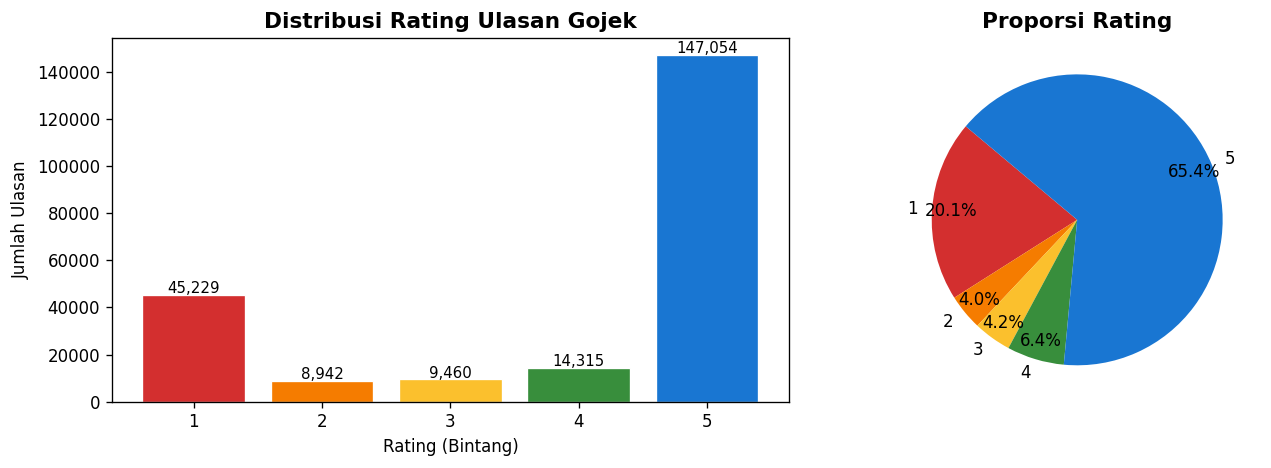

Distribusi rating:
score
1     45229
2      8942
3      9460
4     14315
5    147054
Name: count, dtype: int64


In [ ]:
score_counts = df['score'].value_counts().sort_index()
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Rating Ulasan Gojek', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
for i, (idx, val) in enumerate(zip(score_counts.index, score_counts.values)):
  axes[0].text(idx, val + 800, f'{val:,}', ha='center', fontsize=9)

labels = [f'{int(i)}' for i in score_counts.index]
axes[1].pie(score_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.87, textprops={'fontsize': 10})
axes[1].set_title('Proporsi Rating', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("Distribusi rating:")
print(score_counts)

Rata-rata panjang teks: 51.4 karakter
Rata-rata jumlah kata: 8.5 kata
Ulasan terpendek: 0 kata
Ulasan terpanjang: 104 kata


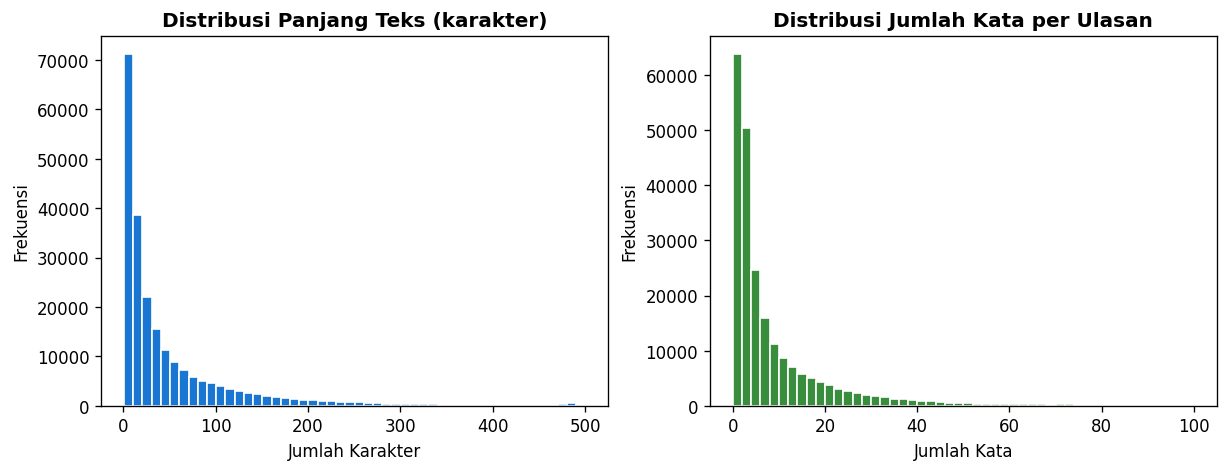

In [ ]:
df['panjang_teks'] = df['content'].apply(len)
df['jumlah_kata'] = df['content'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['panjang_teks'].clip(upper=500), bins=50, color='#1976d2', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks (karakter)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['jumlah_kata'].clip(upper=100), bins=50, color='#388e3c', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Kata per Ulasan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

print(f"Rata-rata panjang teks: {df['panjang_teks'].mean():.1f} karakter")
print(f"Rata-rata jumlah kata: {df['jumlah_kata'].mean():.1f} kata")
print(f"Ulasan terpendek: {df['jumlah_kata'].min()} kata")
print(f"Ulasan terpanjang: {df['jumlah_kata'].max()} kata")

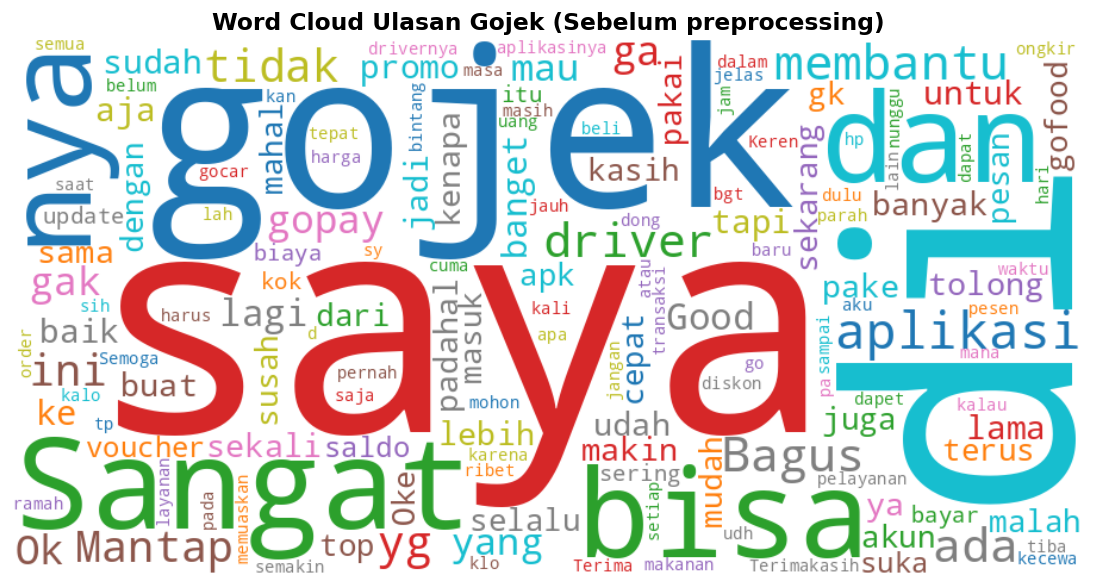

In [ ]:
all_text = ' '.join(df['content'].sample(10000, random_state=42).tolist())
wc = WordCloud(width=900, height=450, background_color='white',
               colormap='tab10', max_words=150,
               collocations=False).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Gojek (Sebelum preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_raw.png', bbox_inches='tight')
plt.show()

In [ ]:
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stop.get_stop_words())

custom_stopwords = {
    'saya', 'sy', 'aku', 'gue', 'gw', 'kita', 'kami',
    'yang', 'yg', 'ini', 'itu', 'ada', 'nya', 'ya', 'ga',
    'gak', 'nggak', 'tidak', 'tak', 'bisa', 'buat', 'jadi',
    'dan', 'di', 'ke', 'dari', 'dengan', 'untuk', 'atau',
    'tapi', 'tp', 'tpy', 'karena', 'karna', 'krn', 'juga',
    'sudah', 'udah', 'udh', 'masih', 'lagi', 'aja', 'saja',
    'sangat', 'banget', 'bgt', 'sekali', 'kali', 'sering',
    'sama', 'mau', 'baru', 'lama', 'terus', 'kok', 'sih',
    'dong', 'deh', 'nih', 'kan', 'lah', 'kah', 'pun',
    'ok', 'oke', 'ok', 'good', 'iya', 'yaa', 'yah',
    'pakai', 'pake', 'maka', 'jelas', 'harus', 'lebih',
    'banyak', 'bagi', 'kalo', 'kalau', 'mah', 'nah',
    'si', 'lo', 'lu', 'kamu', 'anda', 'mereka', 'dia',
    'punya', 'pada', 'dalam', 'oleh', 'jika', 'bila',
    'hingga', 'sampai', 'setelah', 'sebelum', 'ketika',
    'apps', 'app', 'apk', 'aplikasi', 'gojek', 'update',
    'tolong', 'mohon', 'please', 'thanks', 'thank',
    'mantap', 'mantab', 'bagus', 'keren', 'jelek',
    'lain', 'hal', 'beli', 'pakai', 'coba', 'bikin',
    'kaya', 'kayak', 'seperti', 'gimana', 'bagaimana',
    'apa', 'siapa', 'kapan', 'dimana', 'kenapa', 'kenap',
    'gimana', 'mana', 'jauh', 'dekat', 'cepat', 'lambat',
    'tdk', 'tru', 'klo', 'skrg', 'sdh', 'dpt', 'dgn', 'utk', 'krg',
    'bwt', 'otw', 'min', 'gitu', 'tau', 'pas', 'moga', 'gin', 'biar',
    'ala', 'male', 'tuh', 'yuk', 'wkwk', 'haha', 'lol', 'wah', 'wih',
    'dah', 'mulu', 'nih', 'skg', 'gua', 'gue', 'knp', 'smg', 'trs',
    'bener', 'beneran', 'emang', 'emg', 'belum', 'blm', 'bisa', 'bs',
    'ngga', 'ga', 'g', 'udh', 'udah', 'dah', 'deh',
    'plis', 'plz', 'pls', 'btw', 'fyi', 'asli', 'bgt',
}

all_stopwords = sastrawi_stopwords.union(custom_stopwords)
print(f"Total stopwords: {len(all_stopwords)}")

Total stopwords: 913


In [ ]:
def preprocess_text(text):
  """
  Pipeline preprocessing:
  1. Lowercase
  2. Hapus URL, mention, hastag
  3. Hapus angka & karakter non-alfabet
  4. Hapus kata terlalu pendek (< 3 huruf)
  5. Hapus stopwords
  6. Stemming dengan Sastrawi
  """
  if not isinstance(text, str) or len(text.strip()) == 0:
    return ' '

  text = text.lower()
  text = re.sub(r'http\S+|www\S+', ' ', text)
  text = re.sub(r'@\w+|#\w+', ' ', text)
  text = re.sub(r'\d+', ' ', text)
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()
  tokens  = text.split()
  tokens = [t for t in tokens if len(t) >= 3]
  tokens = [t for t in tokens if t not in all_stopwords]
  tokens = [stemmer.stem(t) for t in tokens]
  tokens = [t for t in tokens if t not in all_stopwords and len(t) >= 3]
  return ' '.join(tokens)

test_texts = [
    "Aplikasi gojek sangat bagus, driver ramah dan cepat!",
    "Kenapa saldo gopay saya tiba-tiba berkurang sendiri? tolong diperbaiki",
    "Mantap",
    "Promo gofood sering banget dan ongkirnya gratis"
]

for t in test_texts:
  print(f"Original: {t}")
  print(f"Processed: {preprocess_text(t)}")
  print()

Original: Aplikasi gojek sangat bagus, driver ramah dan cepat!
Processed: driver ramah

Original: Kenapa saldo gopay saya tiba-tiba berkurang sendiri? tolong diperbaiki
Processed: saldo gopay

Original: Mantap
Processed: 

Original: Promo gofood sering banget dan ongkirnya gratis
Processed: promo gofood ongkirnya gratis



In [ ]:
df['content_clean'] = df['content'].progress_apply(preprocess_text)
df_clean = df[df['content_clean'].str.split().str.len() >= 3].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nUlasan sebelum filter : {len(df):,}")
print(f"Ulasan setelah filter : {len(df_clean):,}")
print(f"Ulasan terhapus       : {len(df) - len(df_clean):,}")
print(f"\nContoh hasil preprocessing:")
print(df_clean[['content', 'content_clean']].sample(5, random_state=42).to_string())

  0%|          | 0/225000 [00:00<?, ?it/s]


Ulasan sebelum filter : 225,000
Ulasan setelah filter : 85,891
Ulasan terhapus       : 139,109

Contoh hasil preprocessing:
                                                                                                                                            content                                                                 content_clean
73183                                                                                Sangat membantu tapi kalo musim ujan aplikasi susah di gunakan                                                        bantu musim ujan susah
25506                            Luar biasa mahal ongkir sama makananya ampe setara makanan ongkir sama layananya hadeuh kapok dah mau belanja lagi  mahal ongkir makananya ampe tara makan ongkir layananya hadeuh kapok belanja
78425  asu order gofood ga bisa mulu klo ga eror alesan ga ada driver terus yg nangkring depan resto itu ulet bulu semua makin sini gojek makin asu             asu order gofood eror alesan driver n

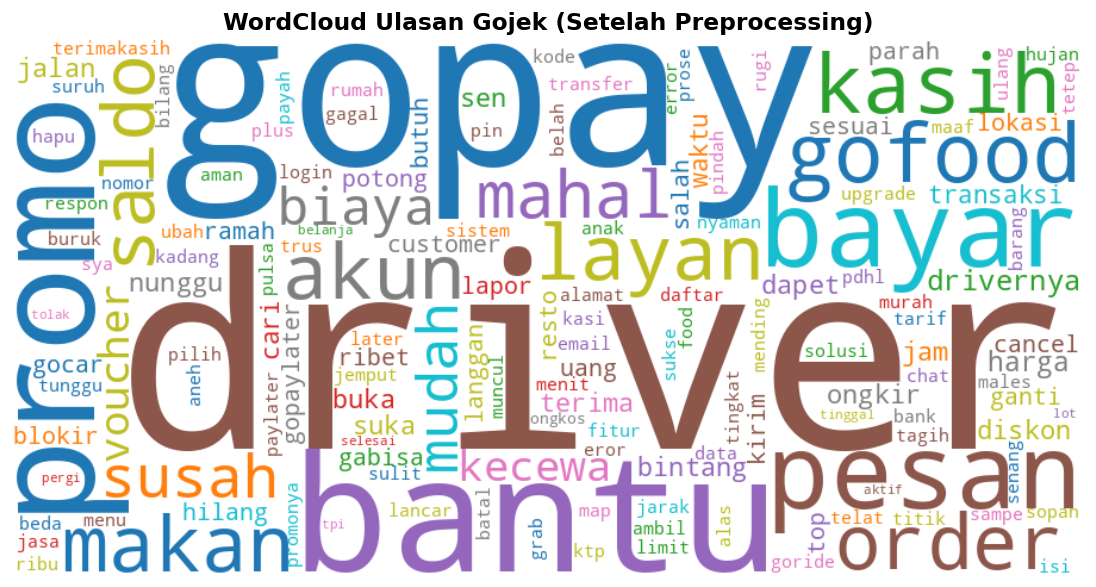

In [ ]:
all_clean_text = ' '.join(df_clean['content_clean'].tolist())
wc_clean = WordCloud(width=900, height=450,
                     background_color='white',
                     colormap='tab10',
                     max_words=150,
                     collocations=False).generate(all_clean_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_clean, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Ulasan Gojek (Setelah Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_clean.png', bbox_inches='tight')
plt.show()

In [ ]:
df_sample = df_clean.sample(n=30000, random_state=42).reset_index(drop=True)
print(f"Data yang digunakan untuk modelling: {len(df_sample):,} ulasan")

count_vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=10,
    max_features=3000,
    ngram_range=(1, 2),
)

dtm_count = count_vectorizer.fit_transform(df_sample['content_clean'])
print(f"Shape Document-Term Matrix: {dtm_count.shape}")
print(f"Jumlah vocab: {len(count_vectorizer.get_feature_names_out()):,}")

Data yang digunakan untuk modelling: 30,000 ulasan
Shape Document-Term Matrix: (30000, 3000)
Jumlah vocab: 3,000


Cari k optimal
Test K=3 Perplexity=861.7
Test K=4 Perplexity=937.8
Test K=5 Perplexity=992.9
Test K=6 Perplexity=1037.1
Test K=7 Perplexity=1102.9
Test K=8 Perplexity=1102.1
Test K=10 Perplexity=1092.0


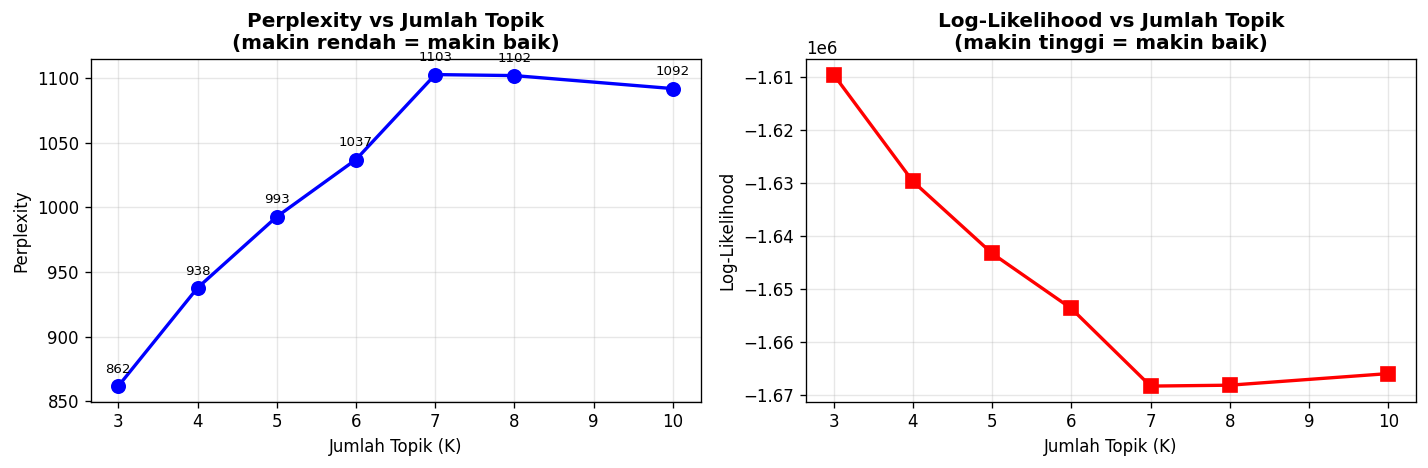


Ringkasan:
  K= 3 | Perplexity=   861.7 | Log-Likelihood=  -1609598.7
  K= 4 | Perplexity=   937.8 | Log-Likelihood=  -1629737.3
  K= 5 | Perplexity=   992.9 | Log-Likelihood=  -1643325.2
  K= 6 | Perplexity=  1037.1 | Log-Likelihood=  -1653714.5
  K= 7 | Perplexity=  1102.9 | Log-Likelihood=  -1668350.0
  K= 8 | Perplexity=  1102.1 | Log-Likelihood=  -1668180.3
  K=10 | Perplexity=  1092.0 | Log-Likelihood=  -1665993.8


In [ ]:
k_values = [3, 4, 5, 6, 7, 8, 10]
perplexities = []
log_likelihoods = []

print("Cari k optimal")
for k in k_values:
  print(f"Test K={k}", end=' ')
  lda = LatentDirichletAllocation(
      n_components=k,
      random_state=42,
      max_iter=20,
      learning_method='online',
      n_jobs=-1,
  )
  lda.fit(dtm_count)
  perplexities.append(lda.perplexity(dtm_count))
  log_likelihoods.append(lda.score(dtm_count))
  print(f"Perplexity={lda.perplexity(dtm_count):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, perplexities, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Topik (K)')
axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity vs Jumlah Topik\n(makin rendah = makin baik)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for k, p in zip(k_values, perplexities):
    axes[0].annotate(f'{p:.0f}', (k, p), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

axes[1].plot(k_values, log_likelihoods, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Topik (K)')
axes[1].set_ylabel('Log-Likelihood')
axes[1].set_title('Log-Likelihood vs Jumlah Topik\n(makin tinggi = makin baik)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_k.png', bbox_inches='tight')
plt.show()

print("\nRingkasan:")
for k, p, ll in zip(k_values, perplexities, log_likelihoods):
    print(f"  K={k:2d} | Perplexity={p:8.1f} | Log-Likelihood={ll:12.1f}")

In [ ]:
K_OPTIMAL = 5

lda_final = LatentDirichletAllocation(
    n_components=K_OPTIMAL,
    random_state=42,
    max_iter=30,
    learning_method='online',
    learning_decay=0.7,
    n_jobs=-1
)

lda_final.fit(dtm_count)

print(f"Model LDA selesai dilatih dengan K={K_OPTIMAL} topik")
print(f"Perplexity final : {lda_final.perplexity(dtm_count):.2f}")
print(f"Log-Likelihood   : {lda_final.score(dtm_count):.2f}")

Model LDA selesai dilatih dengan K=5 topik
Perplexity final : 991.97
Log-Likelihood   : -1643113.16


In [ ]:
feature_names = count_vectorizer.get_feature_names_out()

def get_top_words(model, feature_names, n_top=15):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-n_top-1:-1]
        top_words = [feature_names[i] for i in top_idx]
        topics[idx] = top_words
    return topics

topics_words = get_top_words(lda_final, feature_names, n_top=15)

# Label manual berdasarkan top words (akan diupdate setelah lihat output)
topic_labels_temp = {
    0: "Topik 0",
    1: "Topik 1",
    2: "Topik 2",
    3: "Topik 3",
    4: "Topik 4"
}

print("TOP 15 KATA PER TOPIK")
for idx, words in topics_words.items():
    print(f"\nTopik {idx}: {', '.join(words)}")

TOP 15 KATA PER TOPIK

Topik 0: promo, voucher, suka, diskon, gofood, kirim, butuh, potong, harga, lokasi, ribet, langgan, pilih, nomor, uang

Topik 1: gopay, akun, saldo, buka, blokir, kecewa, lapor, gabisa, upgrade, daftar, suruh, transaksi, ganti, isi, email

Topik 2: bantu, mudah, kasih, terima, ramah, jalan, terima kasih, terimakasih, jemput, aman, pesan, nyaman, sesuai, murah, lancar

Topik 3: driver, order, pesan, makan, gofood, susah, layan, sen, mahal, drivernya, cari, dapet, jam, gocar, cancel

Topik 4: bayar, biaya, gopay, bintang, top, kasih, gopaylater, goride, paylater, hapus, tagih, jasa, later, kasih bintang, limit


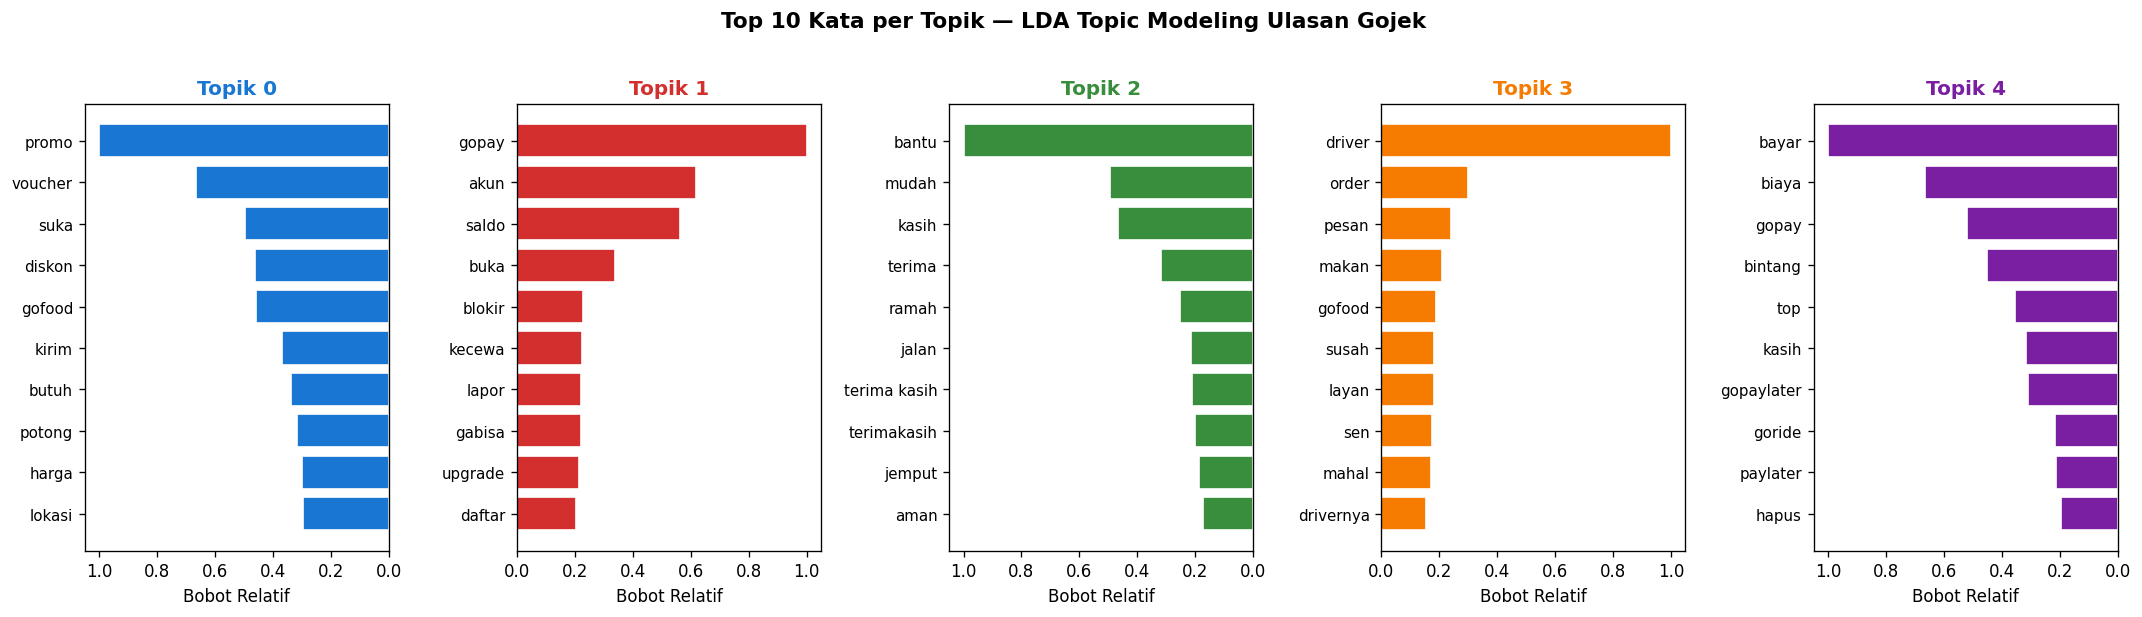

In [ ]:
n_top_words = 10
fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(18, 5))
colors_topic = ['#1976d2', '#d32f2f', '#388e3c', '#f57c00', '#7b1fa2']

for idx, (ax, color) in enumerate(zip(axes, colors_topic)):
    topic = lda_final.components_[idx]
    top_idx = topic.argsort()[:-n_top_words-1:-1]
    top_words = [feature_names[i] for i in top_idx]
    top_weights = [topic[i] for i in top_idx]
    top_weights = np.array(top_weights) / top_weights[0]

    ax.barh(top_words[::-1], top_weights[::-1], color=color, edgecolor='white')
    ax.set_title(f'Topik {idx}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Bobot Relatif')
    ax.tick_params(axis='y', labelsize=9)
    ax.invert_xaxis() if idx % 2 == 0 else None

plt.suptitle('Top 10 Kata per Topik — LDA Topic Modeling Ulasan Gojek',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('topik_barh.png', bbox_inches='tight')
plt.show()

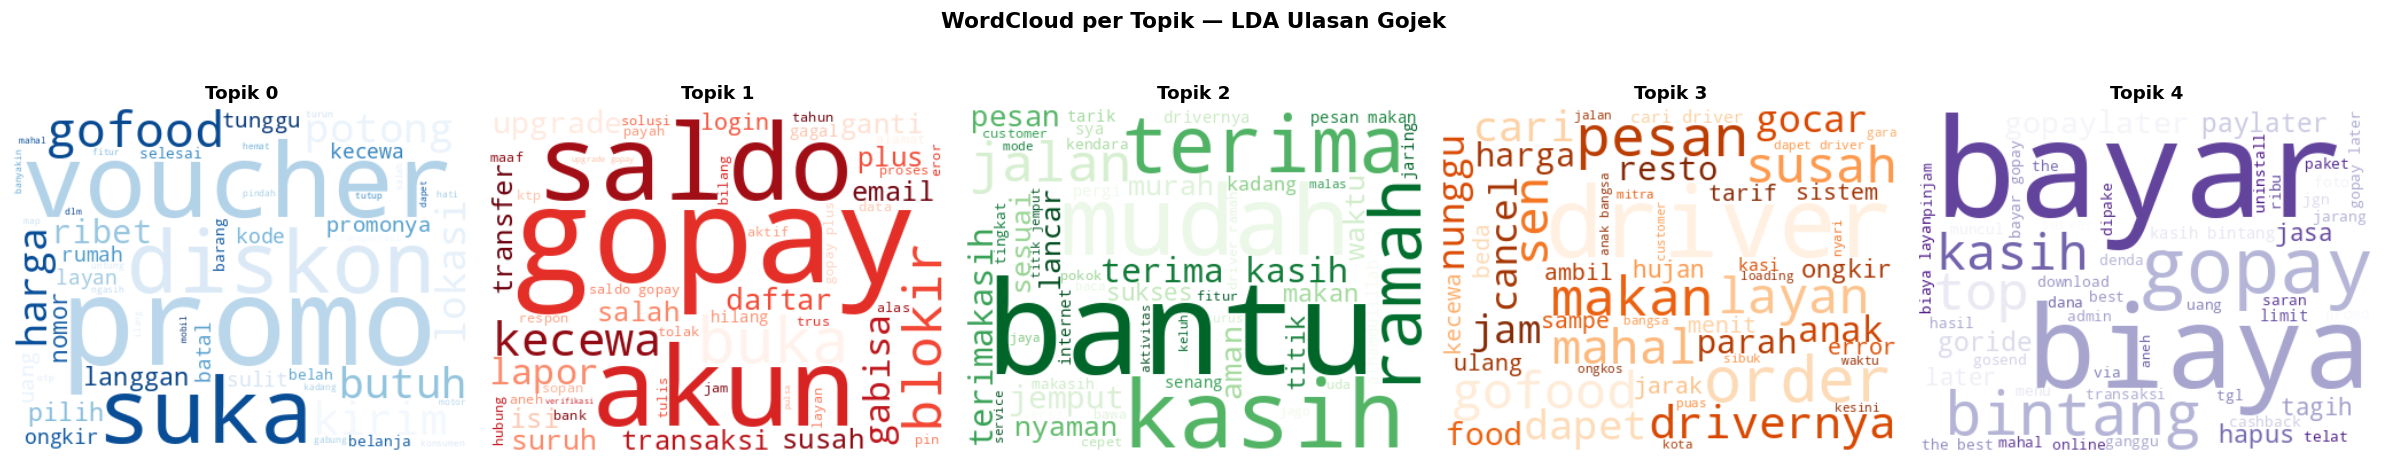

In [ ]:
fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(20, 4))
colors_wc = ['Blues', 'Reds', 'Greens', 'Oranges', 'Purples']

for idx, (ax, cmap) in enumerate(zip(axes, colors_wc)):
    topic = lda_final.components_[idx]
    word_weights = {feature_names[i]: topic[i] for i in range(len(feature_names))}

    wc = WordCloud(width=400, height=300,
                   background_color='white',
                   colormap=cmap,
                   max_words=50,
                   prefer_horizontal=0.9).generate_from_frequencies(word_weights)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topik {idx}', fontsize=11, fontweight='bold')

plt.suptitle('WordCloud per Topik — LDA Ulasan Gojek',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_per_topik.png', bbox_inches='tight')
plt.show()

In [ ]:
doc_topic_dist = lda_final.transform(dtm_count)

# Topik dominan = topik dengan probabilitas tertinggi
df_sample['dominant_topic'] = doc_topic_dist.argmax(axis=1)
df_sample['topic_probability'] = doc_topic_dist.max(axis=1)

topic_dist = df_sample['dominant_topic'].value_counts().sort_index()

print("Distribusi Dokumen per Topik:")
for topic_id, count in topic_dist.items():
    pct = count / len(df_sample) * 100
    top_words_str = ', '.join(topics_words[topic_id][:5])
    print(f"  Topik {topic_id}: {count:,} dok ({pct:.1f}%) | kata kunci: {top_words_str}")

Distribusi Dokumen per Topik:
  Topik 0: 5,523 dok (18.4%) | kata kunci: promo, voucher, suka, diskon, gofood
  Topik 1: 6,186 dok (20.6%) | kata kunci: gopay, akun, saldo, buka, blokir
  Topik 2: 5,615 dok (18.7%) | kata kunci: bantu, mudah, kasih, terima, ramah
  Topik 3: 8,011 dok (26.7%) | kata kunci: driver, order, pesan, makan, gofood
  Topik 4: 4,665 dok (15.6%) | kata kunci: bayar, biaya, gopay, bintang, top


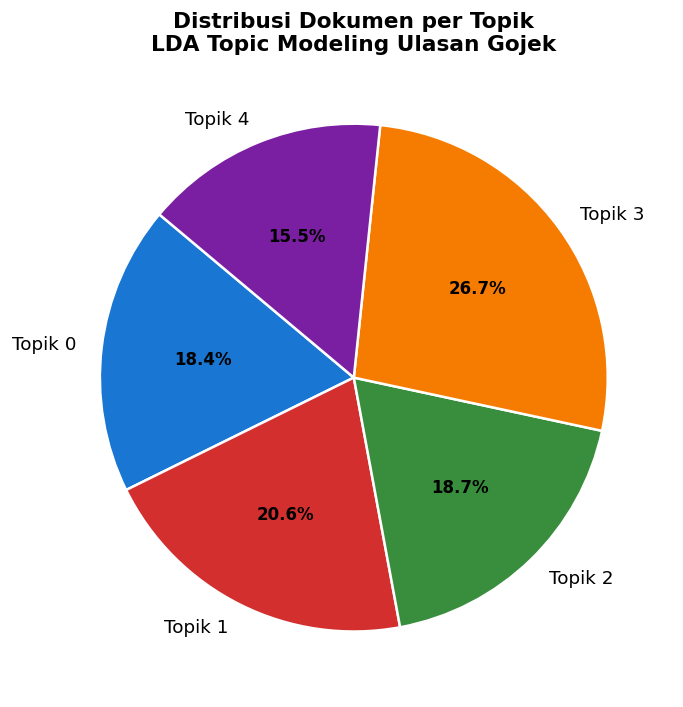

In [ ]:
# Sementara pakai label sementara dulu
labels_temp = [f'Topik {i}' for i in range(K_OPTIMAL)]
colors_pie = ['#1976d2', '#d32f2f', '#388e3c', '#f57c00', '#7b1fa2']
sizes = [topic_dist.get(i, 0) for i in range(K_OPTIMAL)]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_temp, colors=colors_pie,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax.set_title('Distribusi Dokumen per Topik\nLDA Topic Modeling Ulasan Gojek',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_topik.png', bbox_inches='tight')
plt.show()

In [ ]:
topic_labels = {
    0: "Promo & Diskon",
    1: "Masalah Akun & GoPay",
    2: "Kepuasan Layanan",
    3: "Layanan GoFood & Driver",
    4: "Pembayaran & GoPay Later"
}

df_sample['topic_name'] = df_sample['dominant_topic'].map(topic_labels)

print("Label topik berhasil di-assign!")
print(df_sample['topic_name'].value_counts())

Label topik berhasil di-assign!
topic_name
Layanan GoFood & Driver     8011
Masalah Akun & GoPay        6186
Kepuasan Layanan            5615
Promo & Diskon              5523
Pembayaran & GoPay Later    4665
Name: count, dtype: int64


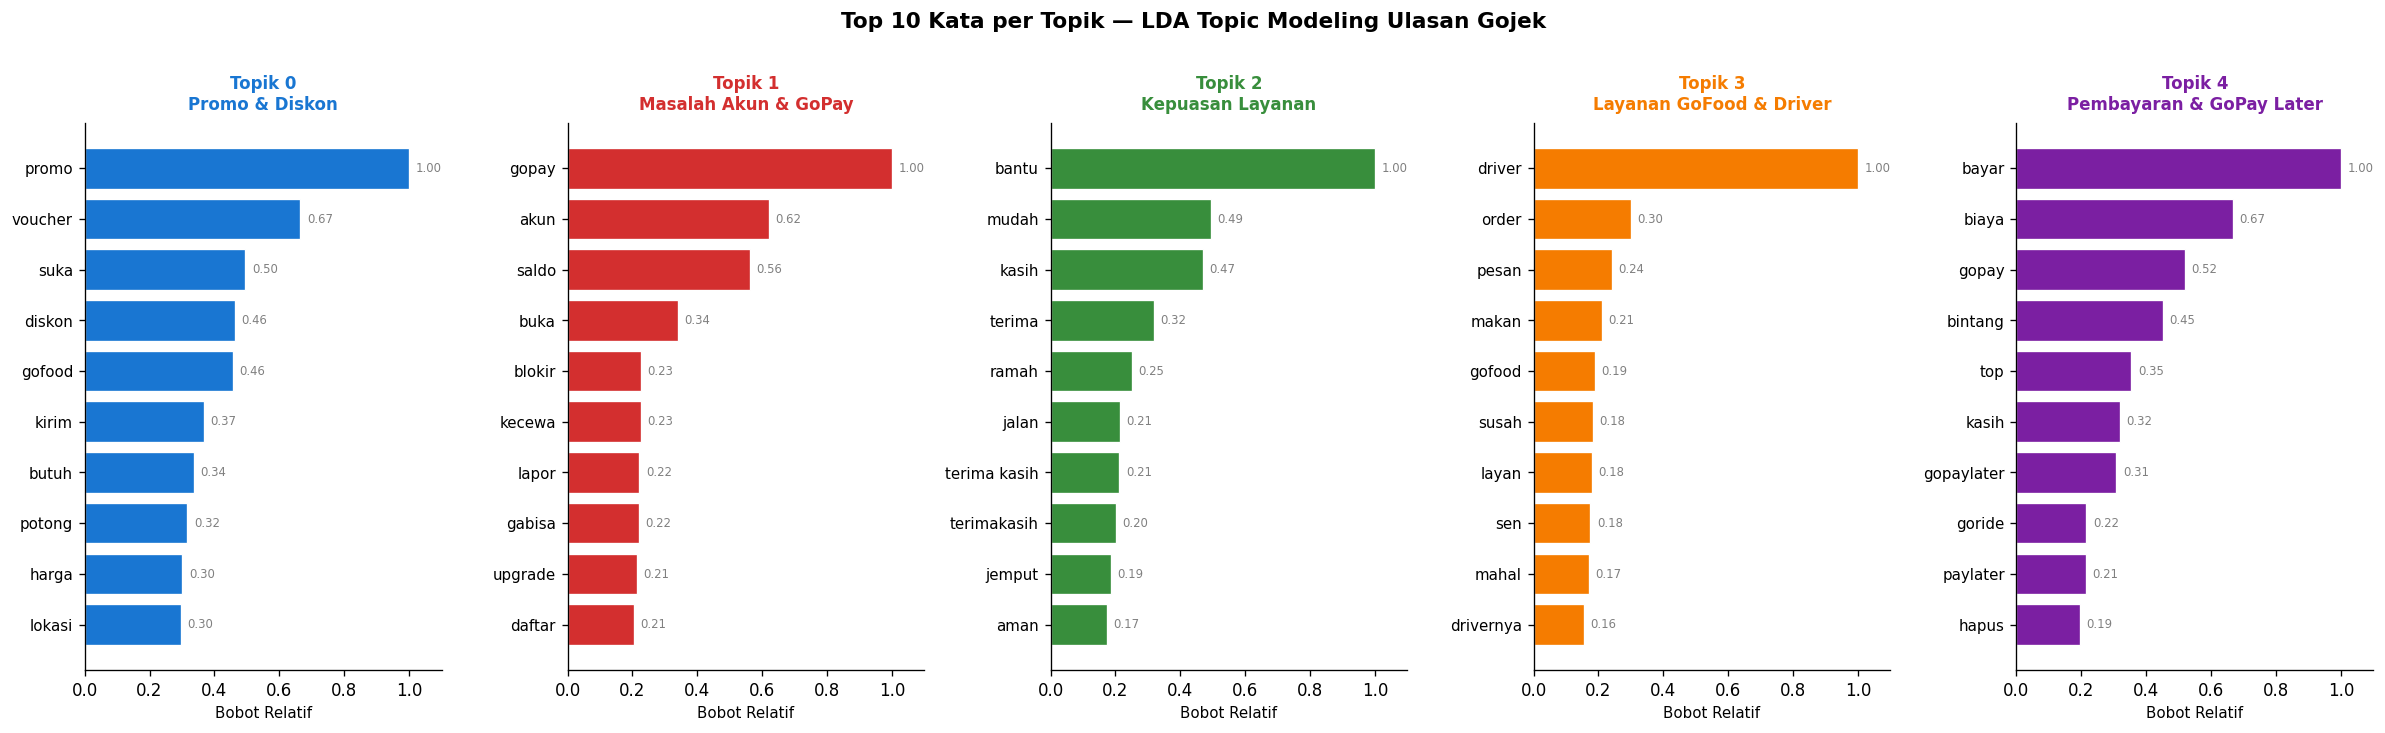

In [ ]:
colors_topic = ['#1976d2', '#d32f2f', '#388e3c', '#f57c00', '#7b1fa2']

fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(20, 6))

for idx, (ax, color) in enumerate(zip(axes, colors_topic)):
    topic = lda_final.components_[idx]
    top_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_idx]
    top_weights = np.array([topic[i] for i in top_idx])
    top_weights = top_weights / top_weights[0]

    bars = ax.barh(top_words[::-1], top_weights[::-1],
                   color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Topik {idx}\n{topic_labels[idx]}',
                 fontsize=10, fontweight='bold', color=color, pad=8)
    ax.set_xlabel('Bobot Relatif', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlim(0, 1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, weight in zip(bars, top_weights[::-1]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{weight:.2f}', va='center', fontsize=7, color='gray')

plt.suptitle('Top 10 Kata per Topik — LDA Topic Modeling Ulasan Gojek',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_barh_topik.png', bbox_inches='tight', dpi=150)
plt.show()

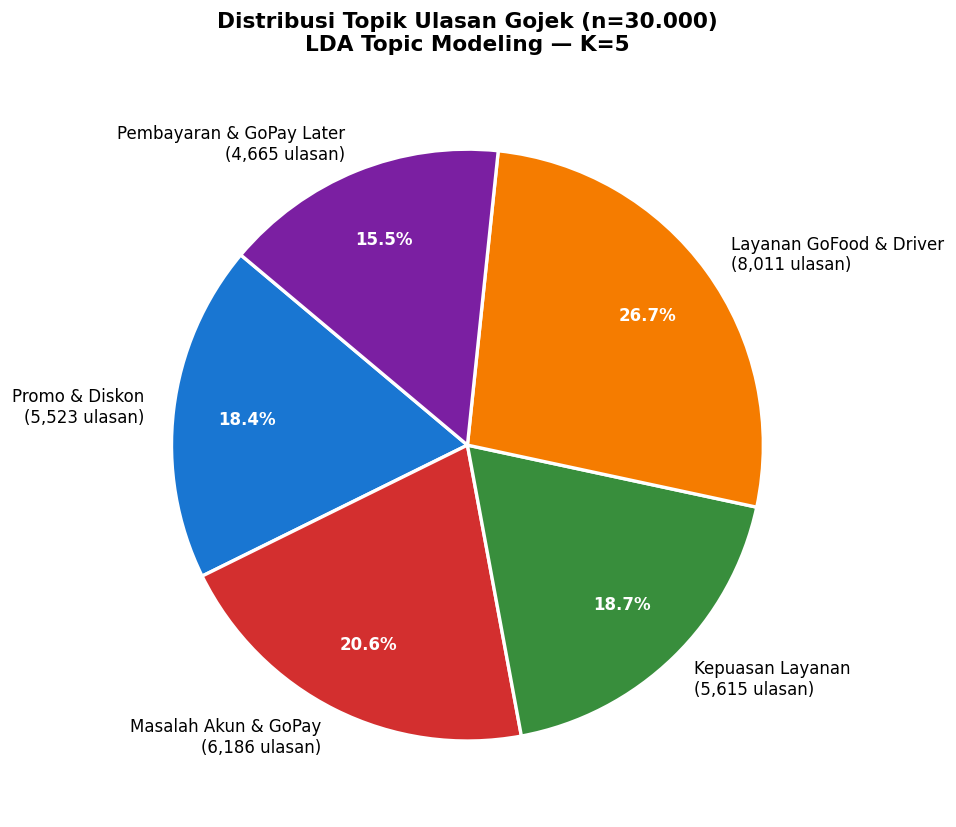

In [ ]:
sizes = [topic_dist.get(i, 0) for i in range(K_OPTIMAL)]
labels_final = [f"{topic_labels[i]}\n({sizes[i]:,} ulasan)" for i in range(K_OPTIMAL)]

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels_final,
    colors=colors_topic,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Distribusi Topik Ulasan Gojek (n=30.000)\nLDA Topic Modeling — K=5',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('final_pie_topik.png', bbox_inches='tight', dpi=150)
plt.show()

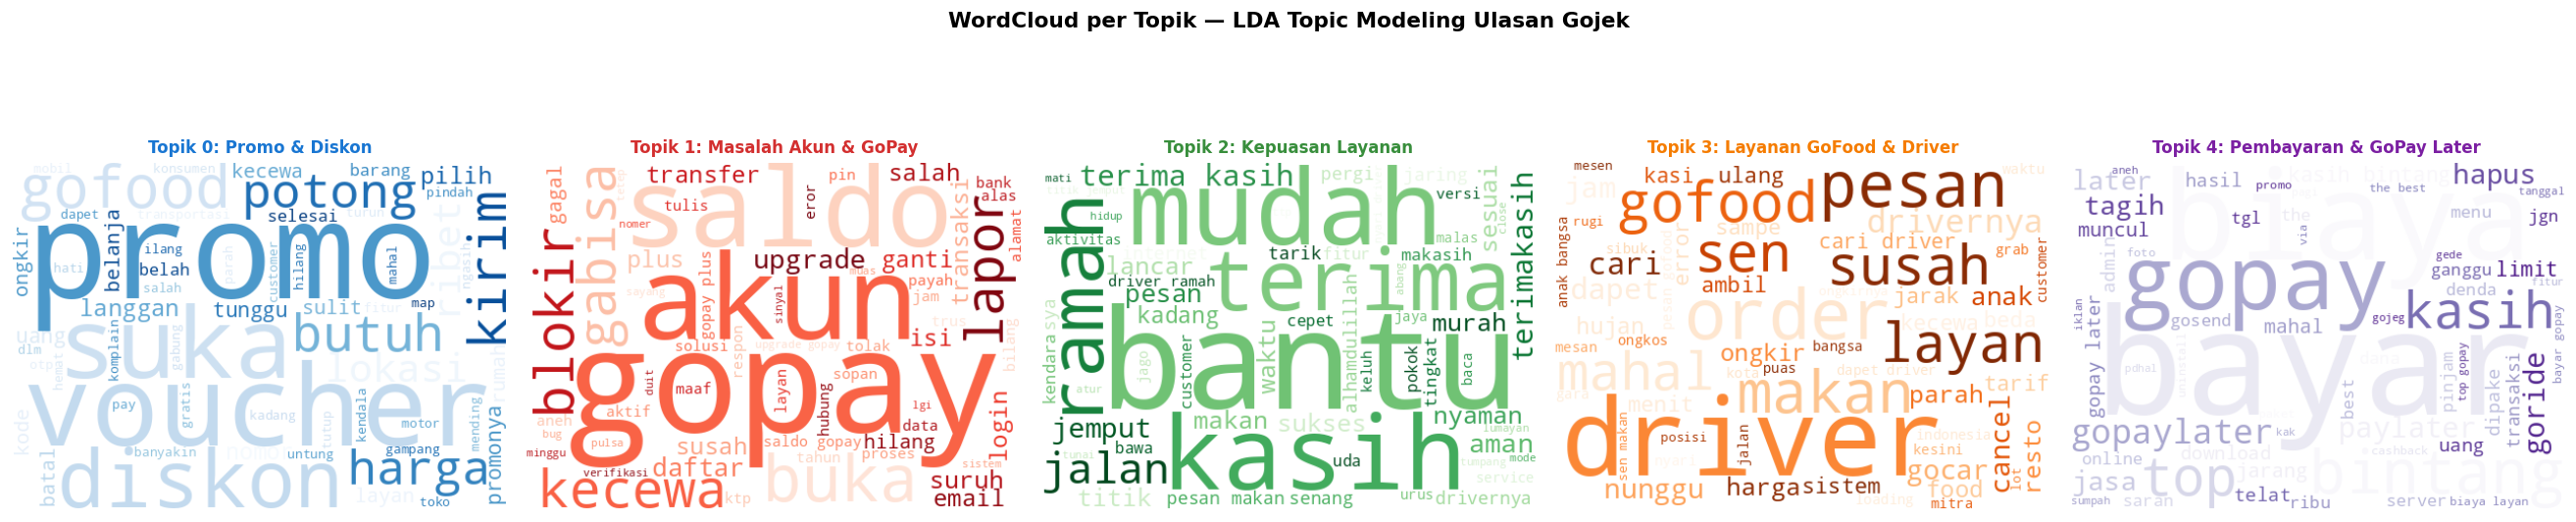

In [ ]:
fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(22, 5))
cmaps = ['Blues', 'Reds', 'Greens', 'Oranges', 'Purples']

for idx, (ax, cmap, color) in enumerate(zip(axes, cmaps, colors_topic)):
    topic = lda_final.components_[idx]
    word_weights = {feature_names[i]: float(topic[i])
                    for i in range(len(feature_names))}

    wc = WordCloud(width=500, height=350,
                   background_color='white',
                   colormap=cmap,
                   max_words=60,
                   prefer_horizontal=0.85,
                   min_font_size=8).generate_from_frequencies(word_weights)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topik {idx}: {topic_labels[idx]}',
                 fontsize=10, fontweight='bold', color=color, pad=6)

plt.suptitle('WordCloud per Topik — LDA Topic Modeling Ulasan Gojek',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_wordcloud_topik.png', bbox_inches='tight', dpi=150)
plt.show()

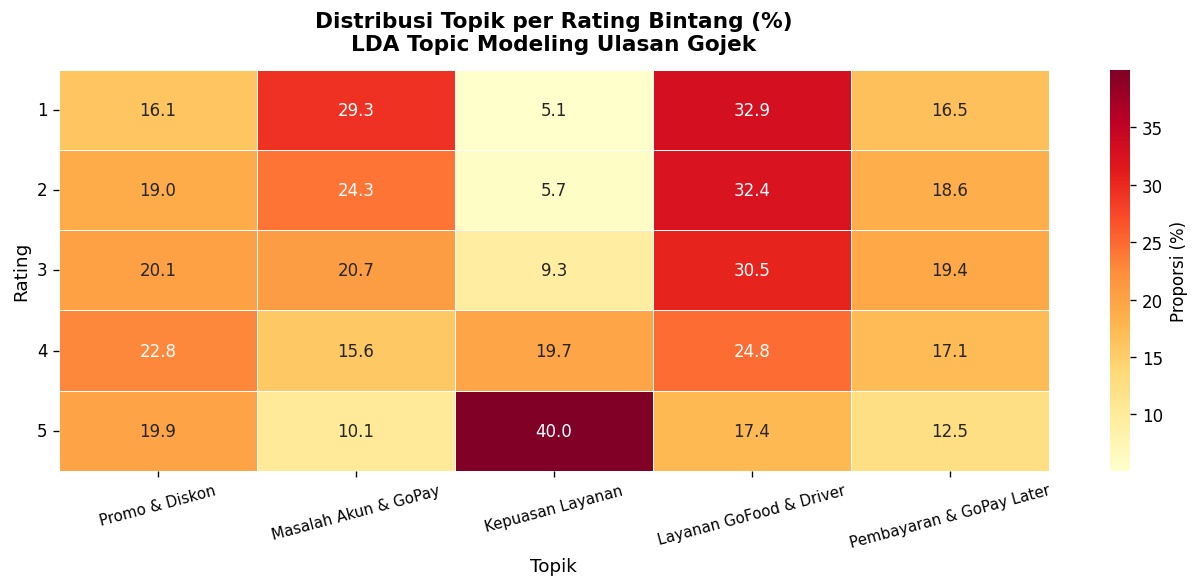

In [ ]:
df_topic_score = df_sample[['score', 'dominant_topic', 'topic_name']].copy()

pivot = df_topic_score.groupby(['score', 'dominant_topic']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.columns = [topic_labels[c] for c in pivot_pct.columns]
pivot_pct.index = [f'{i}' for i in pivot_pct.index]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot_pct,
            annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Proporsi (%)'},
            ax=ax)
ax.set_title('Distribusi Topik per Rating Bintang (%)\nLDA Topic Modeling Ulasan Gojek',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Topik', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)
ax.tick_params(axis='x', rotation=15, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('heatmap_topik_rating.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print("CONTOH ULASAN PER TOPIK (3 sampel per topik)")

for topic_id in range(K_OPTIMAL):
    print(f"TOPIK {topic_id}: {topic_labels[topic_id].upper()}")

    mask = df_sample['dominant_topic'] == topic_id
    samples = df_sample[mask].nlargest(3, 'topic_probability')

    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n[{i}] Rating: {'⭐'*int(row['score'])}")
        print(f"    {row['content'][:200]}")
        print(f"    → Probabilitas topik: {row['topic_probability']:.3f}")

CONTOH ULASAN PER TOPIK (3 sampel per topik)
TOPIK 0: PROMO & DISKON

[1] Rating: ⭐
    Saya kecewa dan kesal karna harga ongkir mahal sekali tolong diturunkan lah harganya yang masuk akal sedikit orang orang juga males liat harga ongkir yang ga masuk akal  promo sedikit banget kalau nga
    → Probabilitas topik: 0.962

[2] Rating: ⭐⭐
    Kecewa sama gojek yg skrg Voucher gofood TDK bs di gabungkan LG Biasa nya voucher toko otomatis terpasang tp skrg hrs di pilih dulu JD ga bs di gabungkan dg voucher dr gojek nya
    → Probabilitas topik: 0.958

[3] Rating: ⭐
    sekarang promo ga bisa di gabung diskon dari resto dan dari voucher promo gofood nya jadi harus pilih salah satu jadi muahallll
    → Probabilitas topik: 0.950
TOPIK 1: MASALAH AKUN & GOPAY

[1] Rating: ⭐
    Ini gojek jelek banget susah buat ganti pin Saya lupa pin mau ganti malah di suruh ganti nomer hp sudah ganti nomer hp masih di minta pin nya Kan saya lupa gimana mau masuk Udah coba ganti nomer hp te
    → Probabilitas t